In [2]:
import os
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

llm = ChatOpenAI(model="gpt-4o-mini")

In [3]:
@tool
def add(a: int, b: int) -> int:
    """두 정수를 더한다"""
    return a+b

@tool
def multiply(a: int, b: int) -> int:
    """두 정수를 곱한다"""
    return a*b

tools = [add, multiply]
llm_with_tools = llm.bind_tools(tools)

In [4]:
# agent -> tools -> agent
class AgentState(TypedDict):
    messages : Annotated[list, add_messages]

tool_map = {t.name : t for t in tools}

def agent_node(state):
    return {'messages' : [llm_with_tools.invoke(state['messages'])]}

def tools_node(state):
    out = []
    for c in state['messages'][-1].tool_calls:
        out.append(ToolMessage(content=str(tool_map[c['name']].invoke(c['args'])), tool_call_id=c['id']))

    return {'messages' : out}

def should_continue(state):
    return "tools" if state['messages'][-1].tool_calls else END
    

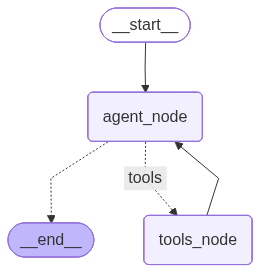

In [5]:
b = StateGraph(AgentState)
b.add_node('agent_node', agent_node)
b.add_node('tools_node', tools_node)

b.add_edge(START, 'agent_node')
b.add_conditional_edges('agent_node', should_continue, {'tools' : 'tools_node', END:END})
b.add_edge('tools_node', 'agent_node')

b.compile()

In [6]:
r = recat_app.invoke({'messages' : [HumanMessage(content='(3+5)*4 는?')]})

In [7]:
[type(m).__name__ for m in r['messages']]

['HumanMessage',
 'AIMessage',
 'ToolMessage',
 'AIMessage',
 'ToolMessage',
 'AIMessage']

In [8]:
@tool
def square(n):
    """정수의 제곱을 반환한다"""
    return n*n

sq_tools = [square]
sq_llm = llm.bind_tools(sq_tools)
sq_map = {t.name : t for t in sq_tools}

In [10]:
class SqState(TypedDict):
    messages : Annotated[list, add_messages]

def sq_agent(state):
    return {'messages': [sq_llm.invoke(state['messages'])]}


def sq_tn(state):
    out = []
    for c in state['messages'][-1].tool_calls:
        out.append(
            ToolMessage(
                content=str(sq_map[c['name']].invoke(c['args'])),
                tool_call_id=c['id']
            )
        )
    return {'messages': out}


def sq_route(state):
    return 'tools' if state['messages'][-1].tool_calls else END


sb_ = StateGraph(SqState)
sb_.add_node('agent', sq_agent)
sb_.add_node('tools', sq_tn)

sb_.add_edge(START, 'agent')
sb_.add_conditional_edges('agent', sq_route, {'tools' : 'tools', END:END})
sb_.add_edge('tools', 'agent')

sq_app = sb_.compile()
sq_app.invoke({'messages' : [HumanMessage(content='7의 제곱은?')]})['messages'][-1].content

'7의 제곱은 49입니다.'

In [ ]:
class AgentState(TypedDict):
    messages : Annotated[list, add_messages]

tool_map = {t.name : t for t in tools}

def agent_node(state):
    return {'messages' : [llm_with_tools.invoke(state['messages'])]}

def tools_node(state):
    out = []
    for c in state['messages'][-1].tool_calls:
        out.append(ToolMessage(content=str(tool_map[c['name']].invoke(c['args'])), tool_call_id=c['id']))

    return {'messages' : out}

def should_continue(state):
    return "tools" if state['messages'][-1].tool_calls else END

b = StateGraph(AgentState)
b.add_node('agent_node', agent_node)
b.add_node('tools_node', tools_node)

b.add_edge(START, 'agent_node')
b.add_conditional_edges('agent_node', should_continue, {'tools' : 'tools_node', END:END})
b.add_edge('tools_node', 'agent_node')

recat_app = b.compile()

In [11]:
from langgraph.prebuilt import ToolNode, tools_condition

b2 = StateGraph(AgentState)
b2.add_node('agent', agent_node)
b2.add_node('tools', ToolNode(tools))

b2.add_edge(START, 'agent')
b2.add_conditional_edges('agent', tools_condition)
b2.add_edge('tools', 'agent')

auto_app = b2.compile()

In [12]:
r = auto_app.invoke({'messages' : [HumanMessage(content='(3+5)*4 는?')]})

In [13]:
r['messages'][-1].content

'(3 + 5) * 4 = 32입니다.'

In [14]:
@tool
def add(a: int, b: int):
    """두 수를 더한다"""
    return a + b

@tool
def subtract(a: int, b: int):
    """두 수를 뺀다"""
    return a - b

@tool
def multiply(a: int, b: int):
    """두 수를 곱한다"""
    return a * b

tools = [add, subtract, multiply]
llm_with_tools = llm.bind_tools(tools)
tool_map = {t.name: t for t in tools}


class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

def agent_node(state):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

def tools_node(state):
    out = []
    for c in state['messages'][-1].tool_calls:
        out.append(
            ToolMessage(
                content=str(tool_map[c['name']].invoke(c['args'])),
                tool_call_id=c['id']
            )
        )
    return {'messages': out}

def should_continue(state):
    return "tools" if state['messages'][-1].tool_calls else END

b = StateGraph(AgentState)
b.add_node('agent_node', agent_node)
b.add_node('tools_node', tools_node)

b.add_edge(START, 'agent_node')
b.add_conditional_edges('agent_node', should_continue, {'tools': 'tools_node', END: END})
b.add_edge('tools_node', 'agent_node')

recat_app = b.compile()
result = recat_app.invoke({
    'messages': [
        HumanMessage(content="반드시 tool을 사용해서 계산해라: 100 + 5 - 2 에 3을 곱하면?")
    ]
})

print(result['messages'][-1].content)

계산 결과는 100 + 5 - 2 에 3을 곱하면 309입니다.


In [17]:
class QState(TypedDict):
    question: str
    qtype: Literal['article', 'case', 'term', 'general']
    answer : str

def classify(state: QState) -> dict:
    response = llm.invoke([
        SystemMessage(content='질믄을 article/case/term/general 중 하나로만 답하세요.'),
        HumanMessage(content=state['question'])
    ])
    qtype = response.content.strip().lower()
    if qtype not in ['article', 'case', 'term', 'general']:
        qtype = 'general'
    return {'qtype' : qtype}

def article_search(s) : return {'answer' : f"[조문 검색] {s['question']}"}
def case_search(s) : return {'answer' : f"[판례 검색] {s['question']}"}
def term_explain(s) : return {'answer' : f"[용어 설명] {s['question']}"}
def general_chat(s) : return {'answer' : f"[일반 대화] {s['question']}"}

def route_by_type(state: QState) -> str:
    return state['qtype']

qb = StateGraph(QState)
qb.add_node('classify', classify)
qb.add_node('article', article_search)
qb.add_node('case', case_search)
qb.add_node('term', term_explain)
qb.add_node('general', general_chat)

qb.add_edge(START, 'classify')
qb.add_conditional_edges('classify', route_by_type, {'article' : 'article', 'case' : 'case', 'term' : 'term', 'general' : 'general'})
qb.add_edge('article', END)
qb.add_edge('case', END)
qb.add_edge('term', END)
qb.add_edge('general', END)

q_app = qb.compile()

In [18]:
q_app.invoke({'question': '민법 제 760조가 뭔가요?', 'qtype': 'general', 'answer':''})

{'question': '민법 제 760조가 뭔가요?',
 'qtype': 'case',
 'answer': '[판례 검색] 민법 제 760조가 뭔가요?'}

In [ ]:
from langgraph.prebuilt import ToolNode, tools_condition

b2 = StateGraph(AgentState)
b2.add_node('agent', agent_node)
b2.add_node('tools', ToolNode(tools))

b2.add_edge(START, 'agent')
b2.add_conditional_edges('agent', tools_condition)
b2.add_edge('tools', 'agent')

auto_app = b2.compile()

In [19]:
memory = MemorySaver()
mem_app = b2.compile(checkpointer=memory)

In [21]:
cfg = {'configurable' : {'thread_id':'alice'}}
mem_app.invoke({'messages' : [HumanMessage(content='내 이름이 뭐였지?')]}, config=cfg)

{'messages': [HumanMessage(content='내이름은 엘리스야', additional_kwargs={}, response_metadata={}, id='dc69823e-b574-4c32-b52c-ca876843a29a'),
  AIMessage(content='안녕하세요, 엘리스! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 103, 'total_tokens': 118, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_43b64008fd', 'id': 'chatcmpl-DaL2qxRAKwKWwzlBAMFrZCGpJXkN5', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dde6b-6dcb-7c33-a88a-2b2826f79772-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 103, 'output_tokens': 15, 'total_tokens': 118, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details

In [22]:
cfg_bob = {'configurable' : {'thread_id':'bob'}}
r = mem_app.invoke({'messages' : [HumanMessage(content='내 이름이 뭐였지?')]}, config=cfg_bob)
r['messages'][-1].content

'죄송하지만, 당신의 이름을 알 수 있는 정보가 없습니다. 이름을 알려주시면 그에 맞춰 대화할 수 있습니다!'